In [ ]:
!pip install ksmesopy --upgrade

In [22]:
import ksmesopy as ms
import matplotlib.pyplot as plt
import numpy as np

### Station metadata

In [23]:
ms.get_stations(names_only=True)[:5]   # first 5 station names

['Alma 5SE', 'Ashland 8S', 'Ashland Bottoms', 'Belleville 2W', 'Bennington 3N']

### Download data
Min/max temperature and wind speed max are **daily-only** variables. Use `list_variables(interval='hour')` to see what is available at each interval.

In [24]:
df_h = ms.request_data(
    station='Manhattan',
    start='2025-06-01',
    end='2025-06-07',
    interval='hour',
    variables=['TEMP2MAVG', 'RELHUM2MAVG', 'SRAVG', 'WSPD2MAVG', 'PRECIP'])
df_h.head(3)

,TIMESTAMP,TEMP2MAVG,RELHUM2MAVG,SRAVG,WSPD2MAVG,PRECIP
0,2025-06-01 00:00:00,18.35,62.11,0.0,0.51,0.0
1,2025-06-01 01:00:00,16.54,71.25,0.0,0.36,0.0
2,2025-06-01 02:00:00,16.97,69.00,0.0,0.83,0.0


In [25]:
df_d = ms.request_data(
    station='Manhattan',
    start='2025-01-01',
    end='2025-12-31',
    interval='day',
    variables=['TEMP2MAVG', 'TEMP2MMIN', 'TEMP2MMAX',
               'RELHUM2MMIN', 'RELHUM2MMAX',
               'SRAVG', 'WSPD2MAVG', 'PRECIP'],
)
df_d.head(3)

,TIMESTAMP,TEMP2MAVG,TEMP2MMIN,TEMP2MMAX,RELHUM2MMIN,RELHUM2MMAX,SRAVG,WSPD2MAVG,PRECIP
0,2025-01-01,0.25,-4.94,5.28,38.80,82.90,114.12,2.03,0.0
1,2025-01-02,2.51,-3.88,8.01,43.47,82.73,82.38,2.83,0.0
2,2025-01-03,-2.26,-6.19,1.80,57.00,85.20,58.45,1.32,0.0


### Meteogram (hourly)

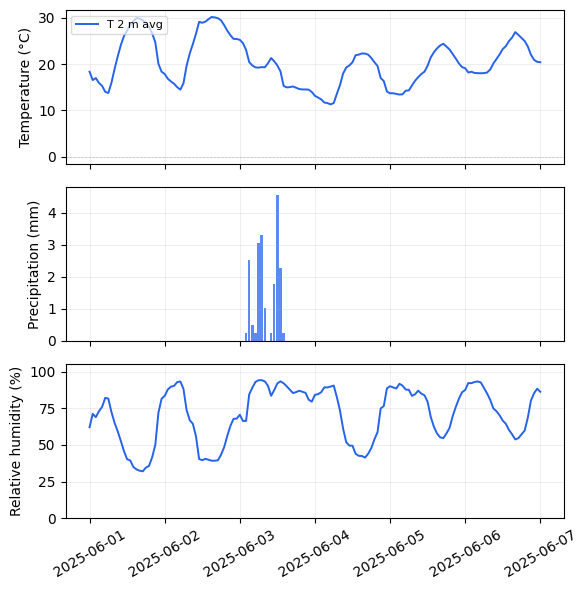

In [26]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(6, 6))
ms.plot_temperature(axes[0], df_h, ['TEMP2MAVG'])
ms.plot_precip(axes[1], df_h, 'PRECIP')
ms.plot_humidity(axes[2], df_h, 'RELHUM2MAVG')
plt.tight_layout()
plt.show()

### Vapor pressure deficit (VPD)
`VPDEFAVG` is measured directly by the station. `vapor_pressure_deficit()` lets you compute it from temperature and relative humidity when only those are available.

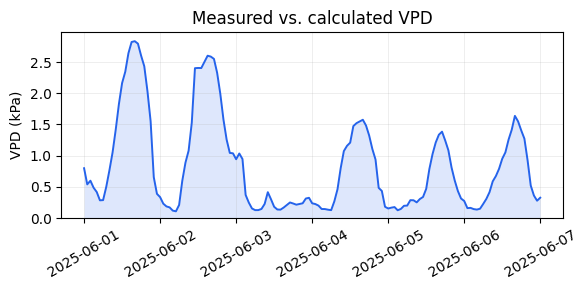

In [27]:
# Compute VPD from T and RH (hourly), then compare to measured VPDEFAVG
df_h['VPD_calc'] = ms.vapor_pressure_deficit(df_h['TEMP2MAVG'], df_h['RELHUM2MAVG'])

fig, ax = plt.subplots(figsize=(6, 3))
ms.plot_vpd(ax, df_h, variables=['VPD_calc'])
ax.set_title('Measured vs. calculated VPD')
plt.tight_layout()
plt.show()

### Solar radiation vs. extraterrestrial radiation
Extraterrestrial radiation (Ra) is the theoretical maximum — the gap between Ra and observed solar radiation reflects cloud cover and atmospheric losses.

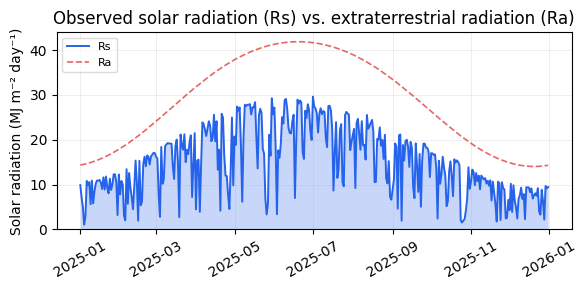

In [29]:
# Station coordinates for Manhattan, KS
LAT, ELEV = 39.19, 325.0

df_d['DOY'] = df_d['TIMESTAMP'].dt.dayofyear
_, Ra = ms.reference_et_penman_monteith(
    df_d['DOY'], LAT, ELEV,
    df_d['TEMP2MMIN'], df_d['TEMP2MMAX'],
    df_d['SRAVG'], df_d['WSPD2MAVG'],
    rhmin=df_d['RELHUM2MMIN'], rhmax=df_d['RELHUM2MMAX'],
)
# Convert SRAVG (W/m², daily average) to MJ/m²/day so both axes share the same unit.
# Ra is already in MJ/m²/day.
df_d['Rs_MJ'] = ms.srad_to_mj(df_d['SRAVG'], 86400)
df_d['Ra_MJ'] = Ra

fig, ax = plt.subplots(figsize=(6, 3))
ms.plot_solar_radiation(ax, df_d, variables=['Rs_MJ', 'Ra_MJ'],
                        ylabel='Solar radiation (MJ m⁻² day⁻¹)')
ax.set_title('Observed solar radiation (Rs) vs. extraterrestrial radiation (Ra)')
plt.tight_layout()
plt.show()

### Reference evapotranspiration (ETo)
Penman-Monteith (FAO-56) requires full met data; Hargreaves–Samani only needs temperature. Both return `(ETo [mm/day], Ra [MJ m⁻² day⁻¹])`.

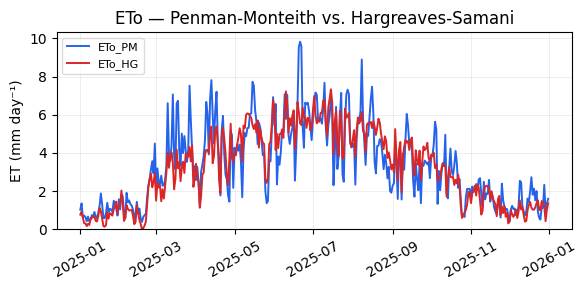

In [30]:
ETo_pm, _ = ms.reference_et_penman_monteith(
    df_d['DOY'], LAT, ELEV,
    df_d['TEMP2MMIN'], df_d['TEMP2MMAX'],
    df_d['SRAVG'], df_d['WSPD2MAVG'],
    rhmin=df_d['RELHUM2MMIN'], rhmax=df_d['RELHUM2MMAX'],
)
ETo_hg, _ = ms.reference_et_hargreaves(
    df_d['DOY'], LAT, df_d['TEMP2MMIN'], df_d['TEMP2MMAX'],
)
df_d['ETo_PM'] = ETo_pm
df_d['ETo_HG'] = ETo_hg

fig, ax = plt.subplots(figsize=(6, 3))
ms.plot_et(ax, df_d, variables=['ETo_PM', 'ETo_HG'])
ax.set_title('ETo — Penman-Monteith vs. Hargreaves-Samani')
plt.tight_layout()
plt.show()

### Soil moisture
Fetch Ka and EC alongside the firmware VWC values, apply the KSU site-specific calibration, then compute storage.

In [31]:
df_soil = ms.request_data(
    station='Manhattan',
    start='2025-01-01',
    end='2025-12-31',
    interval='day',
    variables=[
        'SOILKA5CM', 'SOILKA10CM', 'SOILKA20CM', 'SOILKA50CM',
        'SOILEC5CM', 'SOILEC10CM', 'SOILEC20CM', 'SOILEC50CM',
    ],
)
df_soil = ms.calibrate_vwc(df_soil)
df_soil = ms.compute_soil_water_storage(df_soil)
df_soil.head(3)

,TIMESTAMP,SOILKA5CM,SOILKA10CM,SOILKA20CM,SOILKA50CM,SOILEC5CM,SOILEC10CM,SOILEC20CM,SOILEC50CM,VWC5CM,VWC10CM,VWC20CM,VWC50CM,STORAGE_MM
0,2025-01-01,15.78,19.88,21.31,9.59,0.13898,0.17941,0.21215,0.07991,0.2699,0.3157,0.3294,0.1867,137.8
1,2025-01-02,15.63,19.79,21.23,9.56,0.13900,0.17946,0.21080,0.07917,0.2680,0.3147,0.3286,0.1863,137.4
2,2025-01-03,15.39,19.65,21.16,9.53,0.13438,0.17653,0.20884,0.07869,0.2653,0.3133,0.3280,0.1858,136.9


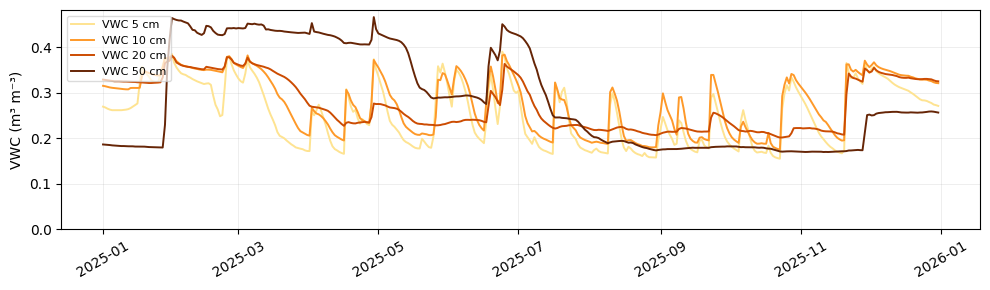

In [32]:
fig, ax = plt.subplots(figsize=(10, 3))
ms.plot_vwc(ax, df_soil)
plt.tight_layout()
plt.show()

### Optional: rename columns to snake_case

In [33]:
ms.rename_columns(df_d).head(3)

,timestamp,t2m,t2m_min,t2m_max,rh_min,rh_max,srad,wspd,precip,DOY,Rs_MJ,Ra_MJ,ETo_PM,ETo_HG
0,2025-01-01,0.25,-4.94,5.28,38.80,82.90,114.12,2.03,0.0,1,9.859968,14.33,1.03,0.77
1,2025-01-02,2.51,-3.88,8.01,43.47,82.73,82.38,2.83,0.0,2,7.117632,14.39,1.36,0.92
2,2025-01-03,-2.26,-6.19,1.80,57.00,85.20,58.45,1.32,0.0,3,5.050080,14.45,0.62,0.60
